In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import datetime
import matplotlib
import seaborn as sns
matplotlib.rcParams['pdf.fonttype'] = 42


294 588
19 7.670068027210885


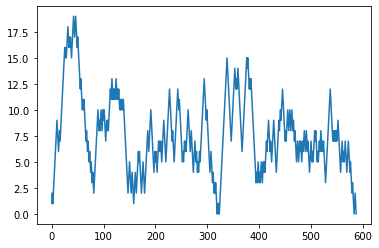

In [75]:
class Job:
    def __init__(self, jid, ts, te):
        self.jid, self.ts, self.te = jid, ts, te

fn = "./cluster_job.log"
with open(fn, 'r') as f:
    content = json.load(f)

jobs = []
events = []
start, end, step = 0, 30000, 20
for item in content[start:end:step]:
    jid = item['jobid']
    if len(item['attempts']) == 0 or item['attempts'][0]['start_time'] == 'None' or item['attempts'][0]['end_time'] == 'None':
        continue
    t_start = datetime.datetime.strptime(item['attempts'][0]['start_time'], "%Y-%m-%d %H:%M:%S")
    t_end = datetime.datetime.strptime(item['attempts'][0]['end_time'], "%Y-%m-%d %H:%M:%S")
    duration = (t_end - t_start).total_seconds()
    if duration >= 3600:
        jobs.append(Job(jid, t_start, t_end))
        events.append((t_start, 1, jid))
        events.append((t_end, -1, jid))

print(len(jobs), len(events))
running_jobs = 0
max_running_jobs = 0
running_job_sizes = []
ts = []
events.sort()
with open(f"trace/philly_{start}_{end}_{step}.trace", 'w') as of:
    for (t, delta_n, jid) in events:
        of.write(f"{jid}, {t}, {delta_n}\n")
for (t, delta_n, jid) in events:
    running_jobs += delta_n
    max_running_jobs = max(max_running_jobs, running_jobs)
    running_job_sizes.append(running_jobs)
    ts.append(t)
    # print(f"{t=}, {running_jobs=}")
plt.plot(running_job_sizes)
print(max_running_jobs, sum(running_job_sizes) / len(running_job_sizes))


[0.  0.2 0.4 0.6] [3837.999999999993, 6829.812359111899, 5986.506782348525, 3415.0000000000014]
[1.  1.2 1.4 1.6] [3950.333333333336, 6864.809115279393, 6760.336150844111, 3583.0000000000023]
[2.  2.2 2.4 2.6] [5387.000000000002, 9190.134238691278, 7363.575490004071, 5352.333333333334]
[3.  3.2 3.4 3.6] [4094.000000000006, 7302.745810412183, 6081.804615801459, 3830.666666666668]


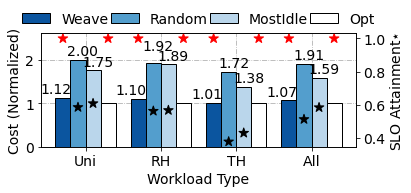

In [84]:
def parse_line(line):
    mix_type, line = line.split("--")
    results = {}
    for method_line in line.split("||"):
        method, *items = method_line.split("|")
        total_cost = float(items[0])
        time_costs = eval(items[1])
        time_invalid_jobs = eval(items[2])
        results[method] = (total_cost, time_costs, time_invalid_jobs)
    return mix_type, results

def cdf(x, plot=True, *args, **kwargs):
    x, y = sorted(x), np.arange(len(x)) / len(x)
    return plt.plot(x, y, *args, **kwargs) if plot else (x, y)

with open("run_results_ablation_type.txt", 'r') as f:
    content = f.read().split("\n")

plt.figure(figsize=(6, 3))
all_costs = {}
all_slos = {}
for line in content:
    if len(line) <= 1:
        continue
    mix_type, results = parse_line(line)
    all_plotted = False
    mix_type_costs = {}
    mix_type_slos = {}
    for method in results:
        total_cost, time_costs, time_invalid_jobs = results[method]
        mix_type_costs[method] = sum([i[2] for i in time_costs])
        num_invalid_jobs = lambda group_invalid_jobs: sum(len(group_invalid_jobs[grp_id]) for grp_id in group_invalid_jobs)
        slo_violation_counts = [num_invalid_jobs(i[2]) for i in time_invalid_jobs]
        slo_attainment_ratio = 1 - (sum(slo_violation_counts) / sum(i[3] for i in time_invalid_jobs) if len(time_invalid_jobs) != 0 else 0)
        mix_type_slos[method] = slo_attainment_ratio
    all_costs[mix_type] = mix_type_costs
    all_slos[mix_type] = mix_type_slos


shift = 0
w = 0.2
hatches = [None, None, None, None]
colors = sns.color_palette('Blues')[::-1][::2] + ['white']
star_colors = ['red', 'black', 'black', 'red']
ax1 = plt.gca()
ax2 = plt.twinx()
for ((mtype, v), (mtype2, slov)) in zip(all_costs.items(), all_slos.items()):
    print(shift + np.arange(len(v)) * w, list(v.values()))
    ax1.bar(shift + np.arange(len(v)) * w, [i/v['Opt'] for i in v.values()], width=w, color=colors[:len(v)], edgecolor='black', label=v.keys() if mtype == 'all' else None, hatch=hatches, zorder=2)
    ax2.scatter(shift + np.arange(len(slov)) * w, list(slov.values()), marker='*', color=star_colors[:len(slov)], s=100)
    for i, (method, mv) in enumerate(v.items()):
        if method != 'Opt':
            h = 0.1
            if mtype == 'rh' and method == 'Random':
                h = 0.3
            ax1.text(shift + i * w - w*0.7 if i != 0 else shift - 1.5*w, mv/v['Opt']+h, "{:.2f}".format((mv/v['Opt'])), fontdict={"fontsize":14}, zorder=2)
    shift += 1


plt.sca(ax2)
plt.yticks(fontsize=14)
plt.ylabel("SLO Attainment$\star$", fontdict={"fontsize": 14})

plt.sca(ax1)
plt.xticks(np.arange(4) + w * 1.5, ['Uni', 'RH', 'TH', 'All'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 2.6)
plt.grid(linestyle='-.', zorder=0)
plt.ylabel("Cost (Normalized)", fontdict={"fontsize": 14})
plt.legend(fontsize=14, ncols=4, frameon=False, columnspacing=0.15, loc='upper center', bbox_to_anchor=(0.5, 1.3))
plt.xlabel("Workload Type", fontdict={"fontsize": 14})
plt.tight_layout()
plt.savefig("ablation_type.pdf")

[0.  0.2 0.4 0.6] [4053.666666666672, 7931.986301961917, 6572.814688415568, 3802.333333333335] [1.0, 0.38847006651884697, 0.4237250554323725, 1]
[1.  1.2 1.4 1.6] [4053.666666666672, 7427.40925764421, 6655.085674763809, 3802.6666666666683] [1.0, 0.49844789356984476, 0.5745011086474501, 1]
[2.  2.2 2.4 2.6] [4053.666666666672, 7183.305838373871, 6038.422921148476, 3795.0000000000014] [1.0, 0.71019955654102, 0.7259423503325942, 1]
[3.  3.2 3.4 3.6] [70.22823182222221, 113.86924515477072, 100.1709143731785, 65.52792106666669] [1.0, 0.5110864745011087, 0.5827050997782706, 1]


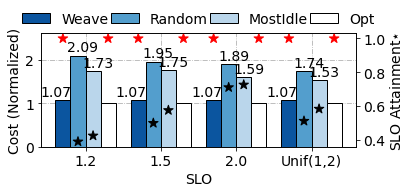

In [87]:
with open("run_results_ablation_slo.txt", 'r') as f:
    content = f.read().split("\n")

plt.figure(figsize=(6, 3))
all_costs_2 = {}
all_slos_2 = {}
for line in content:
    if len(line) <= 1:
        continue
    mix_type, results = parse_line(line)
    all_plotted = False
    mix_type_costs = {}
    mix_type_slos = {}
    for method in results:
        total_cost, time_costs, time_invalid_jobs = results[method]
        mix_type_costs[method] = sum([i[2] for i in time_costs])
        num_invalid_jobs = lambda group_invalid_jobs: sum(len(group_invalid_jobs[grp_id]) for grp_id in group_invalid_jobs)
        slo_violation_counts = [num_invalid_jobs(i[2]) for i in time_invalid_jobs]
        slo_attainment_ratio = 1 - (sum(slo_violation_counts) / sum(i[3] for i in time_invalid_jobs) if len(time_invalid_jobs) != 0 else 0)
        mix_type_slos[method] = slo_attainment_ratio
    all_costs_2[mix_type] = mix_type_costs
    all_slos_2[mix_type] = mix_type_slos


shift = 0
w = 0.2
hatches = [None, None, None, None]
colors = sns.color_palette('Blues')[::-1][::2] + ['white']
star_colors = ['red', 'black', 'black', 'red']
ax1 = plt.gca()
ax2 = plt.twinx()
for ((mtype, v), (mtype2, slov)) in zip(all_costs_2.items(), all_slos_2.items()):
    print(shift + np.arange(len(v)) * w, list(v.values()), list(slov.values()))
    ax1.bar(shift + np.arange(len(v)) * w, [i/v['Opt'] for i in v.values()], width=w, color=colors[:len(v)], edgecolor='black', label=v.keys() if mtype == 'all' else None, hatch=hatches, zorder=2)
    ax2.scatter(shift + np.arange(len(slov)) * w, list(slov.values()), marker='*', color=star_colors[:len(slov)], s=100)
    for i, (method, mv) in enumerate(v.items()):
        if method != 'Opt':
            h = 0.1
            if mtype == 'rh' and method == 'Random':
                h = 0.3
            ax1.text(shift + i * w - w*0.7 if i != 0 else shift - 1.5*w, mv/v['Opt']+h, "{:.2f}".format((mv/v['Opt'])), fontdict={"fontsize":14}, zorder=2)
    shift += 1

shift = 3
w = 0.2
mtype = 'all'
v, slov = all_costs[mtype], all_slos[mtype]
print(shift + np.arange(len(v)) * w, list(v.values()), list(slov.values()))
ax1.bar(shift + np.arange(len(v)) * w, [i/v['Opt'] for i in v.values()], width=w, color=colors[:len(v)], edgecolor='black', label=v.keys() if mtype == 'all' else None, hatch=hatches, zorder=2)
ax2.scatter(shift + np.arange(len(slov)) * w, list(slov.values()), marker='*', color=star_colors[:len(slov)], s=100)
for i, (method, mv) in enumerate(v.items()):
    if method != 'Opt':
        h = 0.1
        if mtype == 'rh' and method == 'Random':
            h = 0.3
        ax1.text(shift + i * w - w*0.7 if i != 0 else shift - 1.5*w, mv/v['Opt']+h, "{:.2f}".format((mv/v['Opt'])), fontdict={"fontsize":14}, zorder=2)


plt.sca(ax2)
plt.yticks(fontsize=14)
plt.ylabel("SLO Attainment$\star$", fontdict={"fontsize": 14})

plt.sca(ax1)
plt.xticks(np.arange(4) + w * 1.5, ['1.2', '1.5', '2.0', 'Unif(1,2)'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 2.6)
plt.grid(linestyle='-.', zorder=0)
plt.ylabel("Cost (Normalized)", fontdict={"fontsize": 14})
plt.legend(fontsize=14, ncols=4, frameon=False, columnspacing=0.15, loc='upper center', bbox_to_anchor=(0.5, 1.3))
plt.xlabel("SLO", fontdict={"fontsize": 14})
plt.tight_layout()
plt.savefig("ablation_slo.pdf")

[Random]Avg=1.57K$/h
Random 924469.1976316998
[MostIdle]Avg=1.31K$/h
MostIdle 769907.8099235366
[Weave]Avg=0.88K$/h
Weave 518267.6479999992
[Opt]Avg=0.82K$/h
Opt 481133.9946666652


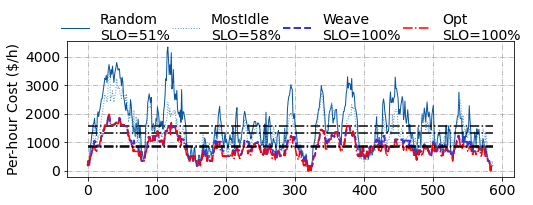

In [104]:
def parse_line(line):
    mix_type, line = line.split("--")
    results = {}
    for method_line in line.split("||"):
        method, *items = method_line.split("|")
        total_cost = float(items[0])
        time_costs = eval(items[1])
        time_invalid_jobs = eval(items[2])
        results[method] = (total_cost, time_costs, time_invalid_jobs)
    return mix_type, results

def cdf(x, plot=True, *args, **kwargs):
    x, y = sorted(x), np.arange(len(x)) / len(x)
    return plt.plot(x, y, *args, **kwargs) if plot else (x, y)

with open("run_results_ablation_type.txt", 'r') as f:
    content = f.read().split("\n")


plt.figure(figsize=(8, 2.5))
all_costs = {}
all_slos = {}
colors = [sns.color_palette('Blues')[-1], sns.color_palette('Blues')[-3], "#3535E0", 'red']
linestyles = ['-', ':', '--', '-.']
linewidths = [1, 1, 2, 1.5]
for line in content:
    if len(line) <= 1:
        continue
    mix_type, results = parse_line(line)
    if mix_type != 'all':
        continue
    all_plotted = False
    mix_type_costs = {}
    mix_type_slos = {}
    weave_costs = {}
    for mid, method in enumerate(['Random', 'MostIdle', "Weave", "Opt"]):
        total_cost, time_costs, time_invalid_jobs = results[method]
        h800_per_hr = 63.296 * 2
        mix_type_costs[method] = total_cost / 3600 * h800_per_hr / 10000
        num_invalid_jobs = lambda group_invalid_jobs: sum(len(group_invalid_jobs[grp_id]) for grp_id in group_invalid_jobs)
        slo_violation_counts = [num_invalid_jobs(i[2]) for i in time_invalid_jobs]
        slo_attainment_ratio = 1 - (sum(slo_violation_counts) / sum(i[3] for i in time_invalid_jobs) if len(time_invalid_jobs) != 0 else 0)
        mix_type_slos[method] = slo_attainment_ratio

        if len(time_costs) == 0:
            continue
        xs, invs, alls, costs = [], [], [], []
        calc_num_invalid_jobs = lambda group_invalid_jobs: sum(len(group_invalid_jobs[grp_id]) for grp_id in group_invalid_jobs)
        t0 = time_costs[0][0]
        for (last_t, t, last_invalid, last_num_all) in time_invalid_jobs:
            invs.append(calc_num_invalid_jobs(last_invalid))
            alls.append(last_num_all)
        for (last_t, t, cost_t) in time_costs:
            xs.append((last_t - t0).total_seconds() / 3600 / 24)
            if method == 'Weave':
                weave_costs[last_t] = cost_t
            if method == 'Opt' and cost_t > weave_costs[last_t]:
                cost_t = weave_costs[last_t]
            costs.append(cost_t * h800_per_hr)
        plt.plot(costs, label=f"{method}\nSLO={slo_attainment_ratio*100:.0f}%", linestyle=linestyles[mid], color=colors[mid], linewidth=linewidths[mid])
        avg_cost = np.average(costs)
        plt.plot([0, len(costs)], [avg_cost, avg_cost], color='black', linestyle='-.', linewidth=1.5)
        print(f"[{method}]Avg={avg_cost/1000:.2f}K$/h")
        # plt.text(len(costs) - 200 - 200 * (mid % 2), 4000 - 800*mid, f"[{method}]Avg={avg_cost/1000:.1f}K$/h", fontdict={"fontsize": 14})
        print(method, sum(costs))
        if not all_plotted:
            # plt.plot(np.arange(len(xs)), alls)
            all_plotted = True

    all_costs[mix_type] = mix_type_costs
    all_slos[mix_type] = mix_type_slos

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(linestyle='-.', zorder=0)
plt.ylabel("Per-hour Cost ($/h)", fontdict={"fontsize": 14})
plt.legend(fontsize=14, ncols=4, frameon=False, columnspacing=0.15, loc='upper center', bbox_to_anchor=(0.5, 1.3))
plt.savefig("time_cost_sim.pdf")